#Assignment 4

This assignment entails creating marketing strategies by analyzing customer purchasing patterns with Age, Annual Income, and Spending Score. Applying KMeans and KMedoids clustering techniques will group customers together based on these factors, and the best results will be analyzed and interpreted to provide actionable insights.

#Version Fix

NumPy 2.x does not support scikit-learn-extra and needs to be reinstalled with the last 1.x version

In [133]:
!pip install numpy==1.26.4 scikit-learn-extra

#Imports

In [161]:
import numpy as np
from numpy import where
import pandas as pd
import matplotlib.pyplot as plt
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [162]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers_Segmentation.csv to Mall_Customers_Segmentation (3).csv


#Dataframe Creation

In [163]:
df = pd.read_csv('Mall_Customers_Segmentation.csv')
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [164]:
df = df.drop(['CustomerID'], axis=1)
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


#Normalized and PCA Initialization

In [165]:
X = df.iloc[:, :]
X = X.to_numpy()

scaler = StandardScaler()
X_n = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_n)

--

--------------------------------------------------------------------------------

--

#KMeans Clustering

#Calculations and Visualization

We will be creating 3 clusters using # of clusters k as [1, 2, 3]

- Uses the normalized data for KMeans calculations
- Uses PCA to visualize the 3 dimensions into 2 dimensions

Output:
- PCA cluster graphs
- Each k clusters silouette score

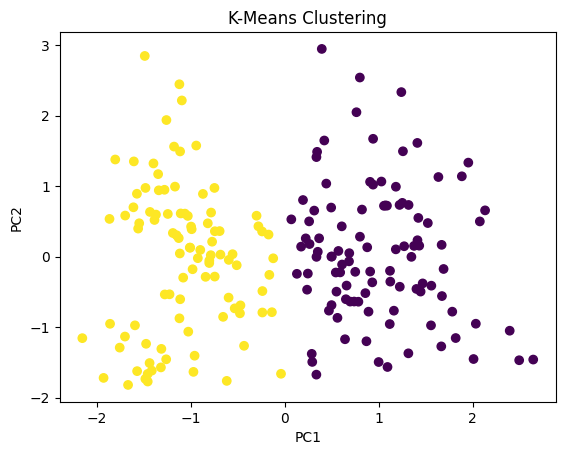

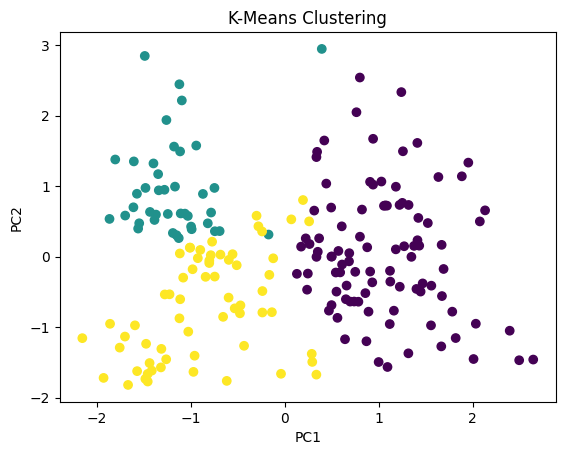

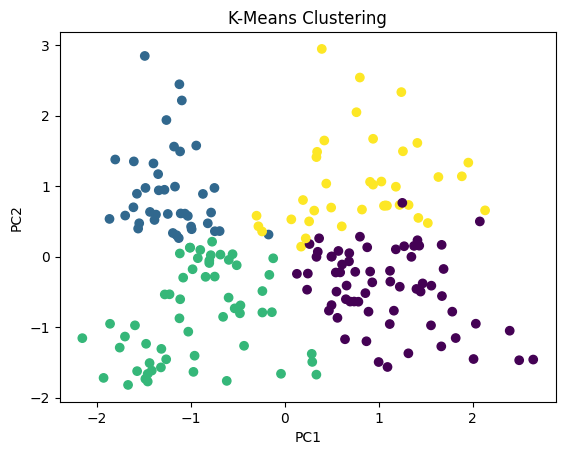

,Clusters,Silhouette Score
0,2,0.335472
1,3,0.357923
2,4,0.403958


In [169]:
resultsKMeans = []
labels = 0

for k in [2, 3, 4]:

  model = KMeans(n_clusters=k, random_state=42)
  labels = model.fit_predict(X_n)
  score = silhouette_score(X_n, labels)

  resultsKMeans.append([k, score])

  # Uses PCA to visualize 3 Dimensions in 2 Dimensions
  plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
  )

  plt.xlabel('PC1')
  plt.ylabel('PC2')
  plt.title('K-Means Clustering')
  plt.show()


print('\n\n\n')


resultsKMeans_df = pd.DataFrame(resultsKMeans, columns=['Clusters', 'Silhouette Score'])
resultsKMeans_df

#Get Best Silhouette Score

In [170]:
bestScoreMeansIdx = resultsKMeans_df['Silhouette Score'].idxmax()
bestScoreMeansIdx

2

#Analyze the best KMeans Cluster

This takes the index of the best silouette score and uses it to find the cluster in the dataframe and is analyzed to return the mean of each feature for each cluster

In [171]:
n = resultsKMeans_df.loc[bestScoreMeansIdx, 'Clusters']
bestKMeans = KMeans(n_clusters=n, random_state=42)
df["KMeansCluster"] = bestKMeans.fit_predict(X)
df.groupby("KMeansCluster").mean()

,Age,Annual Income (k$),Spending Score (1-100)
KMeansCluster,,,
0,44.894737,48.705263,42.631579
1,32.692308,86.538462,82.128205
2,24.821429,28.714286,74.250000
3,40.394737,87.000000,18.631579


--

--------------------------------------------------------------------------------

--

#KMedoids Clustering

#Calculations and Visualization

We will be creating 3 clusters using # of clusters k as [1, 2, 3]

- Uses the normalized data for KMeans calculations
- Uses PCA to visualize the 3 dimensions into 2 dimensions

Output:
- PCA cluster graphs
- Each k clusters silouette score

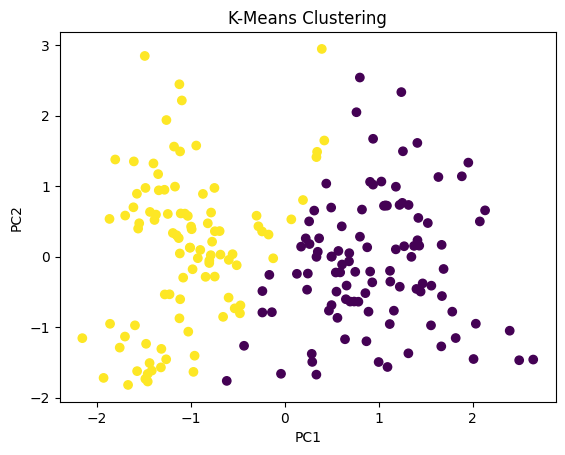

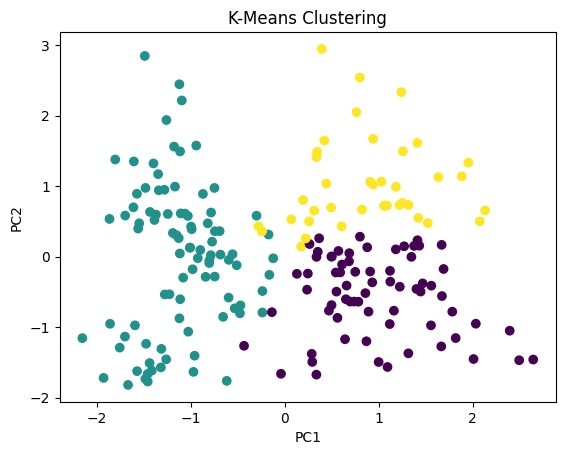

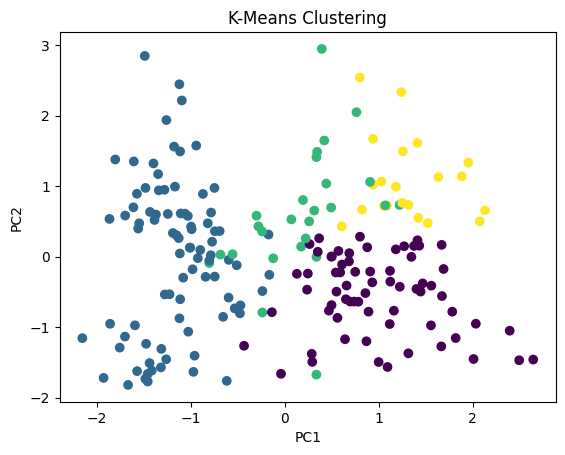

,Clusters,Silhouette Score
0,2,0.316147
1,3,0.347007
2,4,0.280846


In [172]:
resultsKMedoids = []
labels = 0

for k in [2, 3, 4]:

  model = KMedoids(n_clusters=k, random_state=42)
  labels = model.fit_predict(X_n)
  score = silhouette_score(X_n, labels)

  resultsKMedoids.append([k, score])

  # Uses PCA to visualize 3 Dimensions in 2 Dimensions
  plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels
  )

  plt.xlabel('PC1')
  plt.ylabel('PC2')
  plt.title('K-Means Clustering')
  plt.show()


print('\n\n\n')


resultsKMedoids_df = pd.DataFrame(resultsKMedoids, columns=['Clusters', 'Silhouette Score'])
resultsKMedoids_df

#Get Best Silhouette Score

In [173]:
bestScoreMedoidsIdx = resultsKMedoids_df['Silhouette Score'].idxmax()
bestScoreMedoidsIdx

1

#Analyze the best KMedoids Cluster

This takes the index of the best silouette score and uses it to find the cluster in the dataframe and is analyzed to return the mean of each feature for each cluster

In [174]:
n = resultsKMedoids_df.loc[bestScoreMedoidsIdx, 'Clusters']
bestKMedoids = KMedoids(n_clusters=n, random_state=42)
df["KMedoidsCluster"] = bestKMedoids.fit_predict(X)
df.groupby("KMedoidsCluster").mean()

,Age,Annual Income (k$),Spending Score (1-100),KMeansCluster
KMedoidsCluster,,,,
0,38.583333,26.361111,36.916667,0.611111
1,29.419355,69.741935,78.274194,1.145161
2,44.676471,67.049020,37.823529,1.137255
